In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r"C:\Users\AY4Z\Desktop\vois internship major\seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.shape

(4000, 28)

In [5]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [9]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percent
})
missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [4]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df = df.dropna(subset=['Yield_Tonnes_Ha'])

print("Missing values after cleaning:")
print(df.isnull().sum().loc[lambda x: x > 0])

print("\nNew dataset shape:", df.shape)

Missing values after cleaning:
Series([], dtype: int64)

New dataset shape: (3968, 28)


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print("Number of columns:", len(df.columns))
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                        

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Farm_ID:
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [8]:
# Distribution of major categorical variables

print("SEASON DISTRIBUTION")
print(df['Season'].value_counts())

print("\nCROP DISTRIBUTION")
print(df['Crop'].value_counts())

print("\nIRRIGATION METHOD DISTRIBUTION")
print(df['Irrigation_Method'].value_counts())

print("\nSTATE DISTRIBUTION")
print(df['State'].value_counts())

SEASON DISTRIBUTION
Season
Kharif    1772
Rabi      1607
Zaid       589
Name: count, dtype: int64

CROP DISTRIBUTION
Crop
Rice         682
Wheat        612
Maize        547
Cotton       504
Pulses       494
Groundnut    419
Chilli       407
Sugarcane    303
Name: count, dtype: int64

IRRIGATION METHOD DISTRIBUTION
Irrigation_Method
Flood        1296
Rainfed      1037
Drip          907
Sprinkler     728
Name: count, dtype: int64

STATE DISTRIBUTION
State
Andhra Pradesh    525
Telangana         511
Maharashtra       510
Madhya Pradesh    491
Punjab            484
Karnataka         483
Gujarat           483
Tamil Nadu        481
Name: count, dtype: int64


In [9]:
# Season-wise performance overview

season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Fertilizer_kg_ha
Season,,,,,,
Kharif,5.64,46.44,711441.28,179367.12,6094.05,187.04
Rabi,5.08,41.34,601825.55,88197.25,5837.24,185.28
Zaid,4.67,39.15,516662.12,-26592.40,6423.08,184.23


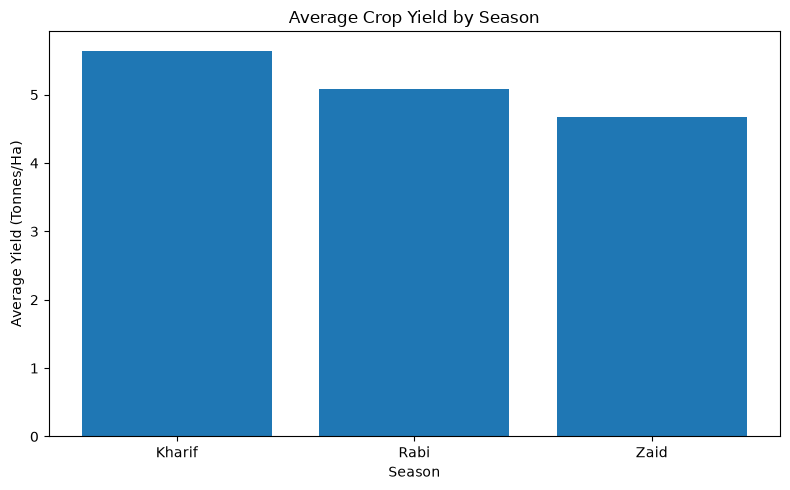

In [10]:
# Seasonal Yield Comparison

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(
    ['Kharif', 'Rabi', 'Zaid']
)

plt.figure(figsize=(8, 5))

plt.bar(season_yield.index, season_yield.values)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

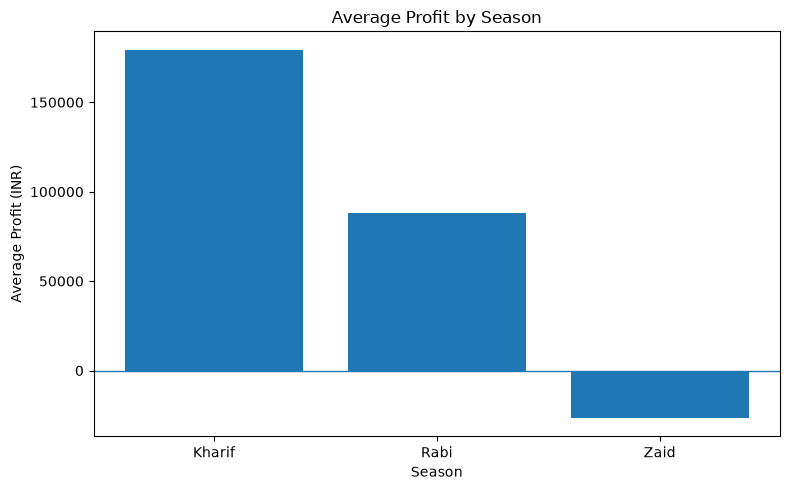

In [11]:
# Seasonal Profit Comparison

season_profit = df.groupby('Season')['Profit_INR'].mean().reindex(
    ['Kharif', 'Rabi', 'Zaid']
)

plt.figure(figsize=(8, 5))

plt.bar(season_profit.index, season_profit.values)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [6]:
# Seasonal Environmental Conditions

environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid']).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20
Rabi,436.00,23.49,57.89,7.59,24.05
Zaid,299.42,31.04,52.01,8.18,19.17


In [7]:
# Seasonal Resource Usage

resource_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Seed_Quality_Score': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid']).round(2)

resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score
Season,,,,
Kharif,6102.20,187.08,5.08,0.82
Rabi,5846.99,185.41,5.02,0.83
Zaid,6419.89,184.64,5.17,0.82


In [8]:
# Crop-wise performance

crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).sort_values('Profit_INR', ascending=False).round(2)

crop_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.94,392.41,1371980.11,817187.99
Chilli,1.54,12.38,1276777.23,750878.34
Cotton,1.23,9.40,639423.08,124546.92
Groundnut,1.32,9.66,542935.50,44858.12
Pulses,0.92,7.40,528465.87,-4238.05
Maize,2.72,21.78,457067.99,-83978.33
Rice,2.44,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34


In [9]:
# Crop distribution across seasons

crop_season = pd.crosstab(df['Crop'], df['Season'])

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


In [10]:
# Average yield for each crop in each season

crop_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).reindex(columns=['Kharif', 'Rabi', 'Zaid']).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


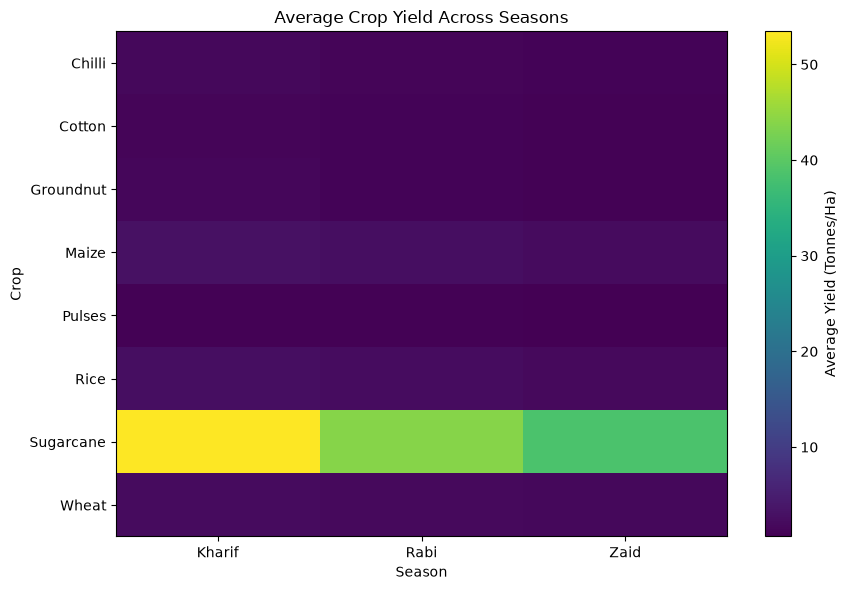

In [11]:
# Crop-wise Yield Across Seasons

plt.figure(figsize=(9, 6))

plt.imshow(crop_season_yield, aspect='auto')

plt.colorbar(label='Average Yield (Tonnes/Ha)')

plt.xticks(
    range(len(crop_season_yield.columns)),
    crop_season_yield.columns
)

plt.yticks(
    range(len(crop_season_yield.index)),
    crop_season_yield.index
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [12]:
# Change in yield from Kharif to Zaid

yield_change = pd.DataFrame({
    'Kharif_Yield': crop_season_yield['Kharif'],
    'Zaid_Yield': crop_season_yield['Zaid']
})

yield_change['Yield_Decline'] = (
    yield_change['Kharif_Yield'] - yield_change['Zaid_Yield']
)

yield_change['Decline_Percentage'] = (
    yield_change['Yield_Decline'] /
    yield_change['Kharif_Yield'] * 100
).round(2)

yield_change.sort_values('Decline_Percentage', ascending=False)

,Kharif_Yield,Zaid_Yield,Yield_Decline,Decline_Percentage
Crop,,,,
Pulses,1.04,0.65,0.39,37.50
Chilli,1.73,1.18,0.55,31.79
Cotton,1.37,0.95,0.42,30.66
Rice,2.71,1.90,0.81,29.89
Groundnut,1.48,1.04,0.44,29.73
Sugarcane,53.46,38.42,15.04,28.13
Wheat,2.26,1.75,0.51,22.57
Maize,2.97,2.30,0.67,22.56


In [13]:
# Seasonal Water Efficiency

water_efficiency = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid']).round(2)

water_efficiency

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
Season,,,
Kharif,6102.20,5.89,5.64
Rabi,5846.99,5.19,5.08
Zaid,6419.89,4.41,4.67


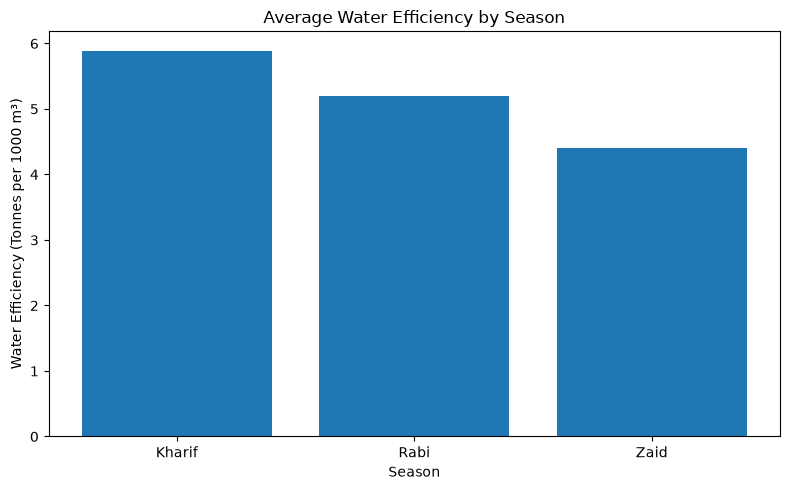

In [14]:
# Water Efficiency by Season

plt.figure(figsize=(8, 5))

plt.bar(
    water_efficiency.index,
    water_efficiency['Water_Efficiency_t_per_1000m3']
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')

plt.tight_layout()
plt.show()

In [15]:
# Relationship between water usage and yield

correlation = df[['Water_Used_m3', 'Yield_Tonnes_Ha']].corr()

correlation

,Water_Used_m3,Yield_Tonnes_Ha
Water_Used_m3,1.000000,0.388653
Yield_Tonnes_Ha,0.388653,1.000000


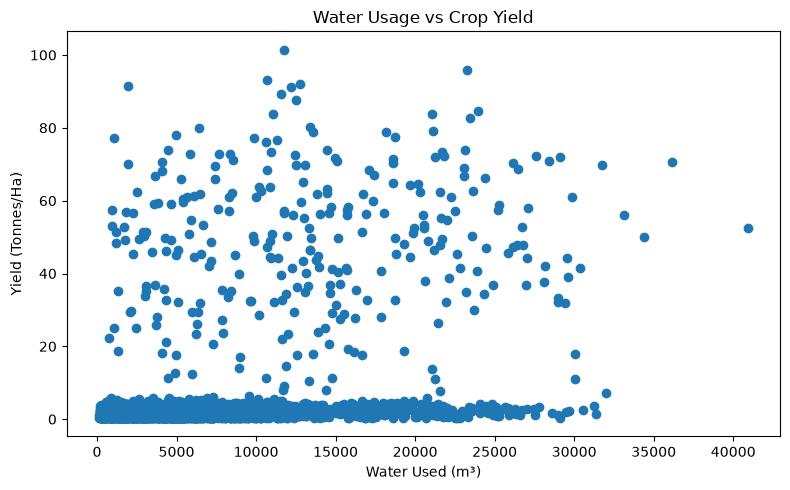

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Water_Used_m3'], df['Yield_Tonnes_Ha'])

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [16]:
# Correlation of agricultural factors with yield

factors = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

yield_correlations = df[factors + ['Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop(
    'Yield_Tonnes_Ha'
).sort_values(ascending=False).round(3)

yield_correlations

Water_Used_m3            0.389
Nitrogen_kg_ha           0.054
Phosphorus_kg_ha         0.048
Rainfall_mm              0.031
Disease_Pest_Risk_pct    0.013
Humidity_pct             0.011
Soil_Moisture_pct        0.010
Avg_Temperature_C        0.009
Potassium_kg_ha          0.004
Fertilizer_kg_ha         0.001
Seed_Quality_Score      -0.007
Pesticide_Litre_ha      -0.008
Sunlight_Hours_Day      -0.015
Soil_pH                 -0.021
Name: Yield_Tonnes_Ha, dtype: float64

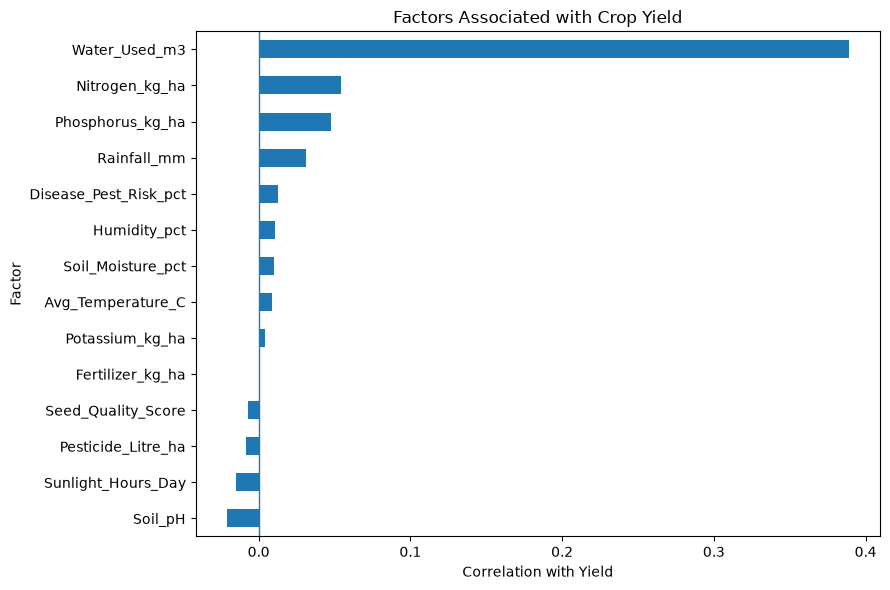

In [17]:
# Correlation of factors with crop yield

plt.figure(figsize=(9, 6))

yield_correlations.sort_values().plot(kind='barh')

plt.title('Factors Associated with Crop Yield')
plt.xlabel('Correlation with Yield')
plt.ylabel('Factor')

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import f_oneway

kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Results")
print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

ANOVA Results
F-statistic: nan
P-value: nan


In [22]:
if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in yield across seasons.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in yield across seasons.")

Result: Fail to reject the null hypothesis.
There is no statistically significant difference in yield across seasons.


In [23]:
# Check for non-finite yield values

print("NaN values:", df['Yield_Tonnes_Ha'].isna().sum())
print("Infinite values:", np.isinf(df['Yield_Tonnes_Ha']).sum())

print("\nSeason-wise counts:")
print(df.groupby('Season')['Yield_Tonnes_Ha'].count())

NaN values: 32
Infinite values: 0

Season-wise counts:
Season
Kharif    1772
Rabi      1607
Zaid       589
Name: Yield_Tonnes_Ha, dtype: int64


In [24]:
# Create clean yield groups for ANOVA

kharif_yield = df.loc[
    (df['Season'] == 'Kharif') &
    np.isfinite(df['Yield_Tonnes_Ha']),
    'Yield_Tonnes_Ha'
]

rabi_yield = df.loc[
    (df['Season'] == 'Rabi') &
    np.isfinite(df['Yield_Tonnes_Ha']),
    'Yield_Tonnes_Ha'
]

zaid_yield = df.loc[
    (df['Season'] == 'Zaid') &
    np.isfinite(df['Yield_Tonnes_Ha']),
    'Yield_Tonnes_Ha'
]

print("Kharif:", len(kharif_yield))
print("Rabi:", len(rabi_yield))
print("Zaid:", len(zaid_yield))

Kharif: 1772
Rabi: 1607
Zaid: 589


In [25]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Results")
print("F-statistic:", round(f_stat, 3))
print("P-value:", p_value)

ANOVA Results
F-statistic: 1.458
P-value: 0.23283549440053075


In [26]:
from scipy.stats import f_oneway

kharif_profit = df.loc[df['Season'] == 'Kharif', 'Profit_INR']
rabi_profit = df.loc[df['Season'] == 'Rabi', 'Profit_INR']
zaid_profit = df.loc[df['Season'] == 'Zaid', 'Profit_INR']

f_stat_profit, p_value_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Profit ANOVA Results")
print("F-statistic:", round(f_stat_profit, 3))
print("P-value:", p_value_profit)

Profit ANOVA Results
F-statistic: 34.292
P-value: 1.7124156677397292e-15


In [27]:
if p_value_profit < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Profit differs significantly across seasons.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("No statistically significant difference in profit across seasons.")

Result: Reject the null hypothesis.
Profit differs significantly across seasons.


In [28]:
# Performance by Irrigation Method

irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean'
}).sort_values('Profit_INR', ascending=False).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3
Irrigation_Method,,,
Drip,6.62,219626.00,5918.75
Sprinkler,5.19,91121.08,6208.26
Rainfed,4.61,79050.37,3549.55
Flood,4.90,73354.02,8026.47


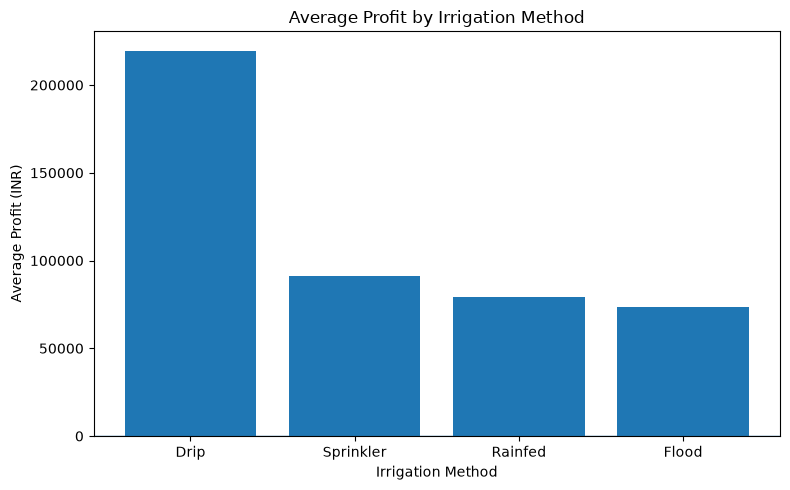

In [29]:
# Profit Comparison by Irrigation Method

plt.figure(figsize=(8, 5))

plt.bar(
    irrigation_summary.index,
    irrigation_summary['Profit_INR']
)

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()